In [28]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.stats import kruskal
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

# Windows에서는 Malgun Gothic이 보통 잘 동작합니다.
# Mac / Linux에서는 다른 한글 폰트로 바꿔야 할 수 있습니다.
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 이번 노트북의 핵심 원칙

- 행정동-분기 600행을 그대로 군집화하지 않고, **행정동 단위 feature table**을 만든 뒤 군집화합니다.
- YoY 기반 변수는 2023년에 구조적 결측이 생길 수 있으므로, `missing flag`를 군집 feature에 넣지 않습니다.
- 증가율 변수는 작은 분모에서 과도하게 커질 수 있으므로, 최근 4분기 평균·변화량·추세 slope를 함께 봅니다.
- 상권활력도는 전체 기간 대비 비중뿐 아니라, 지역 내부 기준인 `open_rate - close_rate`, `(open_cnt - close_cnt) / store_mer_cnt`도 함께 비교합니다.
- 기본 K-Means와 도메인 점수 기반 가중합 K-Means를 함께 비교합니다.

# 인구 카테고리-kmenas

In [29]:
# 파일이 data 폴더 안에 있으니까 여기 중요!
base_dir = Path("../data")

pop_feature_path = base_dir / "population_floating_external_inflow_features.csv"
pop_meta_path = base_dir / "population_floating_external_inflow_feature_meta.csv"

pop_features = pd.read_csv(pop_feature_path, encoding="utf-8-sig")
pop_meta = pd.read_csv(pop_meta_path, encoding="utf-8-sig")

print("pop_features 크기:", pop_features.shape)
print("pop_meta 크기:", pop_meta.shape)

display(pop_features.head())
display(pop_meta.drop(columns=["담당"], errors="ignore"))

pop_features 크기: (600, 25)
pop_meta 크기: (19, 6)


,base_quarter,adm_dong_cd,adm_dong_nm,gu,year,quarter,floating_pop,floating_pop_log,floating_pop_recent4_mean,floating_pop_recent4_mean_log,floating_pop_recent4_change,floating_pop_slope_4q,floating_pop_qoq,floating_pop_qoq_adj,floating_pop_yoy,external_inflow,external_inflow_log,external_inflow_ratio,external_inflow_recent4_mean,external_inflow_recent4_mean_log,external_inflow_recent4_change,external_inflow_slope_4q,external_inflow_qoq,external_inflow_qoq_adj,external_inflow_yoy
0,2023Q1,41131510,신흥1동,수정구,2023,1,781803.43,13.569360,781803.430000,13.569360,NaN,NaN,NaN,NaN,NaN,144654.77,11.882112,18.502703,144654.7700,11.882112,NaN,NaN,NaN,NaN,NaN
1,2023Q2,41131510,신흥1동,수정구,2023,2,808998.65,13.603554,795401.040000,13.586603,NaN,27195.220,3.478524,-4.255088,NaN,143051.02,11.870964,17.682479,143852.8950,11.876553,NaN,-1603.750,-1.108674,-7.757331,NaN
2,2023Q3,41131510,신흥1동,수정구,2023,3,807881.77,13.602172,799561.283333,13.591820,NaN,13039.170,-0.138057,1.945335,NaN,142650.12,11.868157,17.657302,143451.9700,11.873763,NaN,-1002.325,-0.280250,2.551340,NaN
3,2023Q4,41131510,신흥1동,수정구,2023,4,860145.94,13.664859,814707.447500,13.610586,78342.51,23391.065,6.469284,7.938979,NaN,154428.02,11.947490,17.953700,146195.9825,11.892710,9773.25,2891.885,8.256495,8.882617,NaN
4,2024Q1,41131510,신흥1동,수정구,2024,1,779105.37,13.565903,814032.932500,13.609757,-29893.28,-3741.567,-9.421723,-5.377871,-0.345107,136317.24,11.822747,17.496637,144111.6000,11.878350,-6733.78,-842.344,-11.727651,-6.664627,-5.763744


,구분,원본변수,파생변수,유형,계산방식,사용메모
0,유동인구,floating_pop,floating_pop,raw,original value,current scale
1,유동인구,floating_pop,floating_pop_log,log,log1p(floating_pop),scale with outlier compression
2,유동인구,floating_pop,floating_pop_recent4_mean,recent 4Q,rolling mean over last 4 quarters,stable recent scale
3,유동인구,floating_pop,floating_pop_recent4_mean_log,recent 4Q log,log1p(recent4_mean),stable recent scale with outlier compression
4,유동인구,floating_pop,floating_pop_recent4_change,recent 4Q change,current quarter - value 3 quarters ago,recent 4-quarter amount change
5,유동인구,floating_pop,floating_pop_slope_4q,recent 4Q slope,linear slope over last 4 quarters,recent trend
6,유동인구,floating_pop,floating_pop_qoq,QoQ,quarter-over-quarter change rate (%),short-term change
7,유동인구,floating_pop,floating_pop_qoq_adj,QoQ adjusted,1%-99% clipped QoQ - quarter median,relative change within same quarter
8,유동인구,floating_pop,floating_pop_yoy,YoY,same-quarter year-over-year change rate (%),seasonality-adjusted annual change
9,외부유입인구,external_inflow,external_inflow,raw,original value,current scale


In [30]:
# =========================================================
# 2단계. 인구 최종 후보 변수 4개 확인
# =========================================================

pop_candidate_4 = [
    "floating_pop_recent4_mean_log",
    "floating_pop_slope_4q",
    "external_inflow_ratio",
    "external_inflow_slope_4q"
]

# 컬럼이 실제로 있는지 확인
print("선택한 후보 변수:")
print(pop_candidate_4)

print("\n실제 존재 여부:")
for col in pop_candidate_4:
    print(col, "->", col in pop_features.columns)

# 후보 변수만 확인
display(
    pop_features[
        ["base_quarter", "adm_dong_nm", "gu"] + pop_candidate_4
    ].head(10)
)

# 결측치 비율 확인
missing_check = (
    pop_features[pop_candidate_4]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

print("\n결측치 비율:")
display(missing_check)

# 기본 통계 확인
display(pop_features[pop_candidate_4].describe().T)

선택한 후보 변수:
['floating_pop_recent4_mean_log', 'floating_pop_slope_4q', 'external_inflow_ratio', 'external_inflow_slope_4q']

실제 존재 여부:
floating_pop_recent4_mean_log -> True
floating_pop_slope_4q -> True
external_inflow_ratio -> True
external_inflow_slope_4q -> True


,base_quarter,adm_dong_nm,gu,floating_pop_recent4_mean_log,floating_pop_slope_4q,external_inflow_ratio,external_inflow_slope_4q
0,2023Q1,신흥1동,수정구,13.569360,NaN,18.502703,NaN
1,2023Q2,신흥1동,수정구,13.586603,27195.220,17.682479,-1603.750
2,2023Q3,신흥1동,수정구,13.591820,13039.170,17.657302,-1002.325
3,2023Q4,신흥1동,수정구,13.610586,23391.065,17.953700,2891.885
4,2024Q1,신흥1동,수정구,13.609757,-3741.567,17.496637,-842.344
5,2024Q2,신흥1동,수정구,13.593300,-23713.531,17.728517,-4405.805
6,2024Q3,신흥1동,수정구,13.567535,-42446.129,16.561889,-10467.834
7,2024Q4,신흥1동,수정구,13.535312,-8326.463,16.527915,-4523.197
8,2025Q1,신흥1동,수정구,13.508305,-13708.759,27.906313,18832.945
9,2025Q2,신흥1동,수정구,13.510875,4843.127,28.195059,35395.793



결측치 비율:


floating_pop_slope_4q            0.083333
external_inflow_slope_4q         0.083333
floating_pop_recent4_mean_log    0.000000
external_inflow_ratio            0.000000
dtype: float64

,count,mean,std,min,25%,50%,75%,max
floating_pop_recent4_mean_log,600.0,14.462768,0.821659,11.984717,14.004968,14.497503,15.024471,16.096908
floating_pop_slope_4q,550.0,39114.134087,94663.316202,-174914.374000,-16938.273000,17528.827000,77264.800750,589424.405000
external_inflow_ratio,600.0,31.722655,9.876675,12.715275,24.523979,30.857028,37.354872,57.704813
external_inflow_slope_4q,550.0,22778.913769,46293.380877,-91414.769000,-4526.558500,10639.817500,41925.765250,378825.460000


In [31]:
# =========================================================
# 3단계. 인구 변수 4개를 행정동 단위로 요약
# 기준: 가장 최근 분기 2025Q4
# =========================================================

pop_candidate_4 = [
    "floating_pop_recent4_mean_log",
    "floating_pop_slope_4q",
    "external_inflow_ratio",
    "external_inflow_slope_4q"
]

# 가장 최근 분기 확인
latest_quarter = pop_features["base_quarter"].max()
print("가장 최근 분기:", latest_quarter)

# 2025Q4 기준으로 행정동별 1행만 추출
pop_dong_4vars = (
    pop_features
    .loc[
        pop_features["base_quarter"] == latest_quarter,
        ["adm_dong_cd", "adm_dong_nm", "gu", "base_quarter"] + pop_candidate_4
    ]
    .copy()
    .reset_index(drop=True)
)

print("행정동 단위 인구 feature 크기:", pop_dong_4vars.shape)

display(pop_dong_4vars.head())

가장 최근 분기: 2025Q4
행정동 단위 인구 feature 크기: (50, 8)


,adm_dong_cd,adm_dong_nm,gu,base_quarter,floating_pop_recent4_mean_log,floating_pop_slope_4q,external_inflow_ratio,external_inflow_slope_4q
0,41131510,신흥1동,수정구,2025Q4,13.520191,14231.960,27.857658,3694.013
1,41131520,신흥2동,수정구,2025Q4,14.946447,117409.240,33.958720,33019.428
2,41131530,신흥3동,수정구,2025Q4,14.267044,44059.841,26.906321,6993.169
3,41131540,태평1동,수정구,2025Q4,14.486275,50259.219,38.702922,27760.309
4,41131550,태평2동,수정구,2025Q4,14.000611,-13897.226,29.768484,-2135.921


In [32]:
# =========================================================
# 4단계. 행정동 단위 인구 feature 점검
# =========================================================

pop_candidate_4 = [
    "floating_pop_recent4_mean_log",
    "floating_pop_slope_4q",
    "external_inflow_ratio",
    "external_inflow_slope_4q"
]

print("행정동 수:", pop_dong_4vars["adm_dong_nm"].nunique())
print("데이터 크기:", pop_dong_4vars.shape)

print("\n결측치 개수:")
display(pop_dong_4vars[pop_candidate_4].isna().sum())

print("\n기본 통계:")
display(pop_dong_4vars[pop_candidate_4].describe().T)

행정동 수: 50
데이터 크기: (50, 8)

결측치 개수:


floating_pop_recent4_mean_log    0
floating_pop_slope_4q            0
external_inflow_ratio            0
external_inflow_slope_4q         0
dtype: int64


기본 통계:


,count,mean,std,min,25%,50%,75%,max
floating_pop_recent4_mean_log,50.0,14.491233,0.848838,12.000864,14.007020,14.532299,15.056013,16.096908
floating_pop_slope_4q,50.0,74411.790380,78654.086007,-55316.931000,24719.010750,55283.475500,104356.032500,417419.123000
external_inflow_ratio,50.0,36.575536,8.286702,26.279598,31.333491,33.604656,39.895306,56.899627
external_inflow_slope_4q,50.0,26838.723680,32721.266671,-8316.409000,8800.296750,18909.338500,32297.782250,195936.608000


In [33]:
# =========================================================
# 5단계. 인구 feature 4개 상관관계 확인
# =========================================================

pop_candidate_4 = [
    "floating_pop_recent4_mean_log",
    "floating_pop_slope_4q",
    "external_inflow_ratio",
    "external_inflow_slope_4q"
]

corr_pop = pop_dong_4vars[pop_candidate_4].corr().round(3)

display(corr_pop)

,floating_pop_recent4_mean_log,floating_pop_slope_4q,external_inflow_ratio,external_inflow_slope_4q
floating_pop_recent4_mean_log,1.000,0.617,0.445,0.566
floating_pop_slope_4q,0.617,1.000,0.340,0.956
external_inflow_ratio,0.445,0.340,1.000,0.432
external_inflow_slope_4q,0.566,0.956,0.432,1.000


In [34]:
# =========================================================
# 6단계. slope 중복 제거 후 대체 후보 변수 확인
# =========================================================

base_features = [
    "floating_pop_recent4_mean_log",
    "external_inflow_ratio",
    "external_inflow_slope_4q"
]

replace_candidates = [
    "floating_pop_yoy",
    "external_inflow_yoy",
    "floating_pop_qoq_adj",
    "external_inflow_qoq_adj",
    "floating_pop_recent4_change",
    "external_inflow_recent4_change"
]

# 실제 존재하는 후보만 남기기
replace_candidates = [
    col for col in replace_candidates
    if col in pop_features.columns
]

latest_quarter = pop_features["base_quarter"].max()

pop_test = (
    pop_features
    .loc[
        pop_features["base_quarter"] == latest_quarter,
        ["adm_dong_cd", "adm_dong_nm", "gu", "base_quarter"] 
        + base_features 
        + replace_candidates
    ]
    .copy()
    .reset_index(drop=True)
)

print("대체 후보 변수:")
print(replace_candidates)

print("\n결측치 확인:")
display(pop_test[base_features + replace_candidates].isna().sum())

print("\n상관관계 확인:")
display(pop_test[base_features + replace_candidates].corr().round(3))

대체 후보 변수:
['floating_pop_yoy', 'external_inflow_yoy', 'floating_pop_qoq_adj', 'external_inflow_qoq_adj', 'floating_pop_recent4_change', 'external_inflow_recent4_change']

결측치 확인:


floating_pop_recent4_mean_log     0
external_inflow_ratio             0
external_inflow_slope_4q          0
floating_pop_yoy                  0
external_inflow_yoy               0
floating_pop_qoq_adj              0
external_inflow_qoq_adj           0
floating_pop_recent4_change       0
external_inflow_recent4_change    0
dtype: int64


상관관계 확인:


,floating_pop_recent4_mean_log,external_inflow_ratio,external_inflow_slope_4q,floating_pop_yoy,external_inflow_yoy,floating_pop_qoq_adj,external_inflow_qoq_adj,floating_pop_recent4_change,external_inflow_recent4_change
floating_pop_recent4_mean_log,1.000,0.445,0.566,-0.307,-0.737,-0.438,-0.415,0.538,0.488
external_inflow_ratio,0.445,1.000,0.432,-0.156,-0.367,-0.385,-0.408,0.304,0.397
external_inflow_slope_4q,0.566,0.432,1.000,0.110,-0.202,-0.279,-0.258,0.920,0.947
floating_pop_yoy,-0.307,-0.156,0.110,1.000,0.826,0.057,0.092,0.230,0.144
external_inflow_yoy,-0.737,-0.367,-0.202,0.826,1.000,0.264,0.288,-0.133,-0.156
floating_pop_qoq_adj,-0.438,-0.385,-0.279,0.057,0.264,1.000,0.969,-0.131,-0.108
external_inflow_qoq_adj,-0.415,-0.408,-0.258,0.092,0.288,0.969,1.000,-0.111,-0.065
floating_pop_recent4_change,0.538,0.304,0.920,0.230,-0.133,-0.131,-0.111,1.000,0.940
external_inflow_recent4_change,0.488,0.397,0.947,0.144,-0.156,-0.108,-0.065,0.940,1.000


In [35]:
# =========================================================
# 7단계. 인구 최종 변수 4개 확정
# =========================================================

population_final_features = [
    "floating_pop_recent4_mean_log",
    "external_inflow_ratio",
    "external_inflow_slope_4q",
    "floating_pop_yoy"
]

pop_final = pop_test[
    ["adm_dong_cd", "adm_dong_nm", "gu", "base_quarter"] 
    + population_final_features
].copy()

print("인구 최종 feature 크기:", pop_final.shape)

display(pop_final.head())
display(pop_final[population_final_features].corr().round(3))

인구 최종 feature 크기: (50, 8)


,adm_dong_cd,adm_dong_nm,gu,base_quarter,floating_pop_recent4_mean_log,external_inflow_ratio,external_inflow_slope_4q,floating_pop_yoy
0,41131510,신흥1동,수정구,2025Q4,13.520191,27.857658,3694.013,-2.368723
1,41131520,신흥2동,수정구,2025Q4,14.946447,33.958720,33019.428,6.025696
2,41131530,신흥3동,수정구,2025Q4,14.267044,26.906321,6993.169,1.666822
3,41131540,태평1동,수정구,2025Q4,14.486275,38.702922,27760.309,0.769564
4,41131550,태평2동,수정구,2025Q4,14.000611,29.768484,-2135.921,-6.018743


,floating_pop_recent4_mean_log,external_inflow_ratio,external_inflow_slope_4q,floating_pop_yoy
floating_pop_recent4_mean_log,1.000,0.445,0.566,-0.307
external_inflow_ratio,0.445,1.000,0.432,-0.156
external_inflow_slope_4q,0.566,0.432,1.000,0.110
floating_pop_yoy,-0.307,-0.156,0.110,1.000


최중 인구 변수 4개 확정

| 변수                              | 의미                   |
| ------------------------------- | -------------------- |
| `floating_pop_recent4_mean_log` | 최근 4분기 유동인구 규모       |
| `external_inflow_ratio`         | 유동인구 중 외부유입 비중       |
| `external_inflow_slope_4q`      | 최근 4분기 외부유입 증가/감소 추세 |
| `floating_pop_yoy`              | 전년 동분기 대비 유동인구 변화율   |


인구 영역에서는 유동인구의 최근 규모, 외부유입 비중, 외부유입 증가 추세, 전년 대비 유동인구 변화율을 최종 변수로 선정했다.

In [36]:
# =========================================================
# 8단계. 현재 사용 중인 data 폴더에 저장
# =========================================================

save_path = base_dir / "population_final_features_4vars.csv"

pop_final.to_csv(save_path, index=False, encoding="utf-8-sig")

print("저장 완료:", save_path)

저장 완료: ..\data\population_final_features_4vars.csv


In [37]:
check = pd.read_csv(save_path, encoding="utf-8-sig")
display(check.head())
print(check.shape)

,adm_dong_cd,adm_dong_nm,gu,base_quarter,floating_pop_recent4_mean_log,external_inflow_ratio,external_inflow_slope_4q,floating_pop_yoy
0,41131510,신흥1동,수정구,2025Q4,13.520191,27.857658,3694.013,-2.368723
1,41131520,신흥2동,수정구,2025Q4,14.946447,33.958720,33019.428,6.025696
2,41131530,신흥3동,수정구,2025Q4,14.267044,26.906321,6993.169,1.666822
3,41131540,태평1동,수정구,2025Q4,14.486275,38.702922,27760.309,0.769564
4,41131550,태평2동,수정구,2025Q4,14.000611,29.768484,-2135.921,-6.018743


(50, 8)


인구 카테고리는 행정동 단위 50행으로 정리했고, 최종 변수는 유동인구 최근 규모, 외부유입 비중, 외부유입 최근 추세, 유동인구 YoY 변화율 4개로 선정했습니다.
- 상관관계 확인 결과 변수 간 중복이 크지 않아 최종 K-Means/XGBoost 입력 변수로 사용 가능합니다.

In [38]:
# =========================================================
# 9단계. 인구 카테고리 K-Means 실행
# =========================================================
population_final_features = [
    "floating_pop_recent4_mean_log",
    "external_inflow_ratio",
    "external_inflow_slope_4q",
    "floating_pop_yoy"
]

X = pop_final[population_final_features].copy()

# 스케일링
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# k=2~5 비교
k_results = []

for_k_range = range(2, 6)

for k in for_k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    
    k_results.append({
        "k": k,
        "silhouette_score": silhouette_score(X_scaled, labels),
        "calinski_harabasz_score": calinski_harabasz_score(X_scaled, labels),
        "davies_bouldin_score": davies_bouldin_score(X_scaled, labels),
        "cluster_sizes": pd.Series(labels).value_counts().sort_index().to_dict()
    })

k_result_df = pd.DataFrame(k_results)
display(k_result_df)

,k,silhouette_score,calinski_harabasz_score,davies_bouldin_score,cluster_sizes
0,2,0.842218,73.214351,0.096332,"{0: 49, 1: 1}"
1,3,0.362679,64.329191,0.766327,"{0: 36, 1: 1, 2: 13}"
2,4,0.348971,60.965271,0.693059,"{0: 34, 1: 1, 2: 1, 3: 14}"
3,5,0.272069,62.002733,0.744782,"{0: 20, 1: 1, 2: 12, 3: 1, 4: 16}"


In [39]:
# =========================================================
# 10단계. k=3 기준 인구 K-Means 결과 확인
# =========================================================

population_final_features = [
    "floating_pop_recent4_mean_log",
    "external_inflow_ratio",
    "external_inflow_slope_4q",
    "floating_pop_yoy"
]

X = pop_final[population_final_features].copy()

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

k = 3
pop_kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
pop_final["pop_cluster"] = pop_kmeans.fit_predict(X_scaled)

print("군집별 행정동 수:")
display(pop_final["pop_cluster"].value_counts().sort_index())

print("\n군집별 평균:")
cluster_profile = (
    pop_final
    .groupby("pop_cluster")[population_final_features]
    .mean()
    .round(3)
)

display(cluster_profile)

print("\n군집별 행정동 목록:")
for c in sorted(pop_final["pop_cluster"].unique()):
    temp = pop_final[pop_final["pop_cluster"] == c]
    print(f"\n[Cluster {c}] 행정동 수: {len(temp)}")
    print(", ".join(temp["adm_dong_nm"].tolist()))

군집별 행정동 수:


pop_cluster
0    36
1     1
2    13
Name: count, dtype: int64


군집별 평균:


,floating_pop_recent4_mean_log,external_inflow_ratio,external_inflow_slope_4q,floating_pop_yoy
pop_cluster,,,,
0,14.280,34.059,12433.609,-0.179
1,12.955,29.278,29426.601,99.912
2,15.194,44.105,66530.744,2.655



군집별 행정동 목록:

[Cluster 0] 행정동 수: 36
신흥1동, 신흥2동, 신흥3동, 태평1동, 태평2동, 태평3동, 태평4동, 수진1동, 단대동, 산성동, 양지동, 위례동, 신촌동, 성남동, 중앙동, 금광1동, 금광2동, 은행1동, 은행2동, 상대원1동, 상대원2동, 상대원3동, 하대원동, 도촌동, 분당동, 수내1동, 수내3동, 정자동, 정자2동, 서현2동, 이매1동, 이매2동, 야탑2동, 판교동, 금곡동, 운중동

[Cluster 1] 행정동 수: 1
수내2동

[Cluster 2] 행정동 수: 13
수진2동, 복정동, 고등동, 시흥동, 정자1동, 정자3동, 서현1동, 야탑1동, 야탑3동, 삼평동, 백현동, 구미1동, 구미동


클러스터 1에서 수내2동 1개만 나오네....

In [40]:
# =========================================================
# 11단계. 수내2동 YoY 급증 원인 확인
# =========================================================

target_dong = "수내2동"

sunae2 = pop_features[
    pop_features["adm_dong_nm"] == target_dong
][[
    "base_quarter",
    "adm_dong_nm",
    "floating_pop",
    "floating_pop_yoy",
    "external_inflow",
    "external_inflow_ratio",
    "external_inflow_slope_4q"
]].copy()

display(sunae2)

,base_quarter,adm_dong_nm,floating_pop,floating_pop_yoy,external_inflow,external_inflow_ratio,external_inflow_slope_4q
360,2023Q1,수내2동,340480.81,NaN,54846.67,16.108594,NaN
361,2023Q2,수내2동,322686.61,NaN,49977.57,15.487959,-4869.100
362,2023Q3,수내2동,349574.35,NaN,58739.19,16.803061,1946.260
363,2023Q4,수내2동,392829.83,NaN,67231.99,17.114787,4591.758
364,2024Q1,수내2동,310057.68,-8.935344,49277.57,15.893033,639.280
365,2024Q2,수내2동,275551.52,-14.607080,41103.15,14.916684,-7086.254
366,2024Q3,수내2동,284623.95,-18.579853,42264.37,14.849197,-8307.728
367,2024Q4,수내2동,263896.08,-32.821782,37862.81,14.347621,-3308.306
368,2025Q1,수내2동,269243.18,-13.163518,80374.91,29.852162,11341.372
369,2025Q2,수내2동,313260.47,13.684900,93066.64,29.709028,19491.891


- 2024Q4 유동인구: 263,896
- 2025Q4 유동인구: 527,560

- 2024Q4 외부유입: 37,862
- 2025Q4 외부유입: 154,460

수내2동은 2024Q4 대비 2025Q4에 유동인구가 약 2배 증가했고, 외부유입은 약 4배 증가했다. 이 때문에 floating_pop_yoy 값이 매우 크게 나타나 단독 군집으로 분리되었다.

Cluster 1은 수내2동 단독 군집으로, 2025년 하반기 유동인구와 외부유입이 급증한 특이 증가형으로 해석된다.

In [41]:
# YoY 상위 행정동 확인
display(
    pop_final[
        ["adm_dong_nm", "floating_pop_yoy", "floating_pop_recent4_mean_log", "external_inflow_ratio"]
    ]
    .sort_values("floating_pop_yoy", ascending=False)
    .head(10)
)

,adm_dong_nm,floating_pop_yoy,floating_pop_recent4_mean_log,external_inflow_ratio
30,수내2동,99.912181,12.954812,29.278308
39,이매2동,23.909975,13.422031,28.637700
41,야탑2동,13.997800,13.862290,31.390941
8,수진2동,8.971797,14.471040,36.632685
35,정자3동,8.003409,14.850025,40.243477
15,고등동,7.557448,14.421870,48.293649
1,신흥2동,6.025696,14.946447,33.958720
9,단대동,5.513276,14.026246,32.243363
47,구미1동,5.248710,14.933678,47.218397
42,야탑3동,3.950365,15.092535,33.570460


In [42]:
# =========================================================
# 12단계. floating_pop_yoy 이상치 완화 후 K-Means 재실행
# =========================================================

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd

pop_final_clip = pop_final.copy()

# floating_pop_yoy 상하위 5% 기준으로 clipping
lower = pop_final_clip["floating_pop_yoy"].quantile(0.05)
upper = pop_final_clip["floating_pop_yoy"].quantile(0.95)

print("floating_pop_yoy clipping 기준")
print("하위 5%:", lower)
print("상위 5%:", upper)

pop_final_clip["floating_pop_yoy_clip"] = pop_final_clip["floating_pop_yoy"].clip(lower, upper)

population_features_clip = [
    "floating_pop_recent4_mean_log",
    "external_inflow_ratio",
    "external_inflow_slope_4q",
    "floating_pop_yoy_clip"
]

X = pop_final_clip[population_features_clip].copy()

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

k_results_clip = []

for k in range(2, 6):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    
    k_results_clip.append({
        "k": k,
        "silhouette_score": silhouette_score(X_scaled, labels),
        "calinski_harabasz_score": calinski_harabasz_score(X_scaled, labels),
        "davies_bouldin_score": davies_bouldin_score(X_scaled, labels),
        "cluster_sizes": pd.Series(labels).value_counts().sort_index().to_dict()
    })

k_result_clip_df = pd.DataFrame(k_results_clip)
display(k_result_clip_df)

floating_pop_yoy clipping 기준
하위 5%: -6.343302950255715
상위 5%: 11.736098768634463


,k,silhouette_score,calinski_harabasz_score,davies_bouldin_score,cluster_sizes
0,2,0.373874,25.689022,1.094602,"{0: 14, 1: 36}"
1,3,0.318361,26.472016,0.901573,"{0: 20, 1: 1, 2: 29}"
2,4,0.289877,28.488037,0.892033,"{0: 20, 1: 1, 2: 12, 3: 17}"
3,5,0.318222,31.730490,0.802120,"{0: 11, 1: 19, 2: 4, 3: 1, 4: 15}"


수내2동은 오류가 아니라 특이 증가 지역으로 보임.
하지만 최종 군집을 안정적으로 만들려면 floating_pop_yoy를 clipping해서 다시 비교하는 게 좋음.

In [43]:
# =========================================================
# 13단계. clipping 적용 후 k=2 최종 인구 K-Means 결과 확인
# =========================================================

population_features_clip = [
    "floating_pop_recent4_mean_log",
    "external_inflow_ratio",
    "external_inflow_slope_4q",
    "floating_pop_yoy_clip"
]

X = pop_final_clip[population_features_clip].copy()

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

k = 2
pop_kmeans_final = KMeans(n_clusters=k, random_state=42, n_init=20)
pop_final_clip["pop_cluster"] = pop_kmeans_final.fit_predict(X_scaled)

print("군집별 행정동 수:")
display(pop_final_clip["pop_cluster"].value_counts().sort_index())

print("\n군집별 평균:")
pop_cluster_profile = (
    pop_final_clip
    .groupby("pop_cluster")[population_features_clip]
    .mean()
    .round(3)
)

display(pop_cluster_profile)

print("\n군집별 행정동 목록:")
for c in sorted(pop_final_clip["pop_cluster"].unique()):
    temp = pop_final_clip[pop_final_clip["pop_cluster"] == c]
    print(f"\n[Cluster {c}] 행정동 수: {len(temp)}")
    print(", ".join(temp["adm_dong_nm"].tolist()))

군집별 행정동 수:


pop_cluster
0    14
1    36
Name: count, dtype: int64


군집별 평균:


,floating_pop_recent4_mean_log,external_inflow_ratio,external_inflow_slope_4q,floating_pop_yoy_clip
pop_cluster,,,,
0,15.201,43.947,63930.894,2.398
1,14.215,33.709,12413.991,0.017



군집별 행정동 목록:

[Cluster 0] 행정동 수: 14
수진2동, 복정동, 고등동, 시흥동, 정자1동, 정자3동, 서현1동, 야탑1동, 야탑3동, 삼평동, 백현동, 금곡동, 구미1동, 구미동

[Cluster 1] 행정동 수: 36
신흥1동, 신흥2동, 신흥3동, 태평1동, 태평2동, 태평3동, 태평4동, 수진1동, 단대동, 산성동, 양지동, 위례동, 신촌동, 성남동, 중앙동, 금광1동, 금광2동, 은행1동, 은행2동, 상대원1동, 상대원2동, 상대원3동, 하대원동, 도촌동, 분당동, 수내1동, 수내2동, 수내3동, 정자동, 정자2동, 서현2동, 이매1동, 이매2동, 야탑2동, 판교동, 운중동


인구 K-Means 최종안
- 변수: 4개
- floating_pop_yoy는 clipping 적용
- k = 2

인구 카테고리는 행정동 단위 50행으로 정리한 뒤 K-Means를 수행했다.

최종 변수는 최근 4분기 유동인구 규모, 외부유입 비중, 외부유입 최근 추세, 유동인구 YoY 변화율 4개를 사용했다.

다만 수내2동의 YoY 값이 약 99.9%로 매우 크게 나타나 군집이 왜곡될 수 있어, 유동인구 YoY는 상하위 5% 기준으로 clipping하여 이상치 영향을 완화했다.

그 결과 k=2에서 군집 크기가 14개 / 36개로 안정적으로 나뉘었고, Cluster 0은 외부유입 고활성형, Cluster 1은 일반 인구 안정형으로 해석했다.

점수는 좋아도 1개짜리 군집이 있으면 주의

In [49]:
# =========================================================
# K-Means 평가 결과 다시 확인
# =========================================================

print("clipping 전 K-Means 결과")
display(k_result_df)

print("clipping 후 K-Means 결과")
display(k_result_clip_df)

clipping 전 K-Means 결과


,k,silhouette_score,calinski_harabasz_score,davies_bouldin_score,cluster_sizes
0,2,0.842218,73.214351,0.096332,"{0: 49, 1: 1}"
1,3,0.362679,64.329191,0.766327,"{0: 36, 1: 1, 2: 13}"
2,4,0.348971,60.965271,0.693059,"{0: 34, 1: 1, 2: 1, 3: 14}"
3,5,0.272069,62.002733,0.744782,"{0: 20, 1: 1, 2: 12, 3: 1, 4: 16}"


clipping 후 K-Means 결과


,k,silhouette_score,calinski_harabasz_score,davies_bouldin_score,cluster_sizes,has_tiny_cluster
0,2,0.373874,25.689022,1.094602,"{0: 14, 1: 36}",False
1,3,0.318361,26.472016,0.901573,"{0: 20, 1: 1, 2: 29}",True
2,4,0.289877,28.488037,0.892033,"{0: 20, 1: 1, 2: 12, 3: 17}",True
3,5,0.318222,31.730490,0.802120,"{0: 11, 1: 19, 2: 4, 3: 1, 4: 15}",True


In [50]:
# =========================================================
# 군집 크기 안정성 확인 컬럼 추가
# =========================================================

k_result_df_check = k_result_df.copy()
k_result_clip_df_check = k_result_clip_df.copy()

k_result_df_check["min_cluster_size"] = k_result_df_check["cluster_sizes"].apply(
    lambda d: min(d.values())
)

k_result_clip_df_check["min_cluster_size"] = k_result_clip_df_check["cluster_sizes"].apply(
    lambda d: min(d.values())
)

k_result_df_check["has_tiny_cluster"] = k_result_df_check["min_cluster_size"] <= 1
k_result_clip_df_check["has_tiny_cluster"] = k_result_clip_df_check["min_cluster_size"] <= 1

print("clipping 전 평가표")
display(k_result_df_check)

print("clipping 후 평가표")
display(k_result_clip_df_check)

clipping 전 평가표


,k,silhouette_score,calinski_harabasz_score,davies_bouldin_score,cluster_sizes,min_cluster_size,has_tiny_cluster
0,2,0.842218,73.214351,0.096332,"{0: 49, 1: 1}",1,True
1,3,0.362679,64.329191,0.766327,"{0: 36, 1: 1, 2: 13}",1,True
2,4,0.348971,60.965271,0.693059,"{0: 34, 1: 1, 2: 1, 3: 14}",1,True
3,5,0.272069,62.002733,0.744782,"{0: 20, 1: 1, 2: 12, 3: 1, 4: 16}",1,True


clipping 후 평가표


,k,silhouette_score,calinski_harabasz_score,davies_bouldin_score,cluster_sizes,has_tiny_cluster,min_cluster_size
0,2,0.373874,25.689022,1.094602,"{0: 14, 1: 36}",False,14
1,3,0.318361,26.472016,0.901573,"{0: 20, 1: 1, 2: 29}",True,1
2,4,0.289877,28.488037,0.892033,"{0: 20, 1: 1, 2: 12, 3: 17}",True,1
3,5,0.318222,31.730490,0.802120,"{0: 11, 1: 19, 2: 4, 3: 1, 4: 15}",True,1


In [45]:
# =========================================================
# pop_cluster_name 컬럼 추가
# =========================================================

cluster_name_map = {
    0: "외부유입 고활성형",
    1: "일반 인구 안정형"
}

pop_final_clip["pop_cluster_name"] = pop_final_clip["pop_cluster"].map(cluster_name_map)

print(pop_final_clip[["adm_dong_nm", "pop_cluster", "pop_cluster_name"]].head())

  adm_dong_nm  pop_cluster pop_cluster_name
0        신흥1동            1        일반 인구 안정형
1        신흥2동            1        일반 인구 안정형
2        신흥3동            1        일반 인구 안정형
3        태평1동            1        일반 인구 안정형
4        태평2동            1        일반 인구 안정형


In [46]:
# =========================================================
# 15단계. 인구 K-Means 결과 PCA 시각화용 데이터 생성
# =========================================================

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

# 군집명 컬럼이 없으면 생성
cluster_name_map = {
    0: "외부유입 고활성형",
    1: "일반 인구 안정형"
}

if "pop_cluster_name" not in pop_final_clip.columns:
    pop_final_clip["pop_cluster_name"] = pop_final_clip["pop_cluster"].map(cluster_name_map)

# 최종 인구 K-Means에 사용한 변수
population_features_clip = [
    "floating_pop_recent4_mean_log",
    "external_inflow_ratio",
    "external_inflow_slope_4q",
    "floating_pop_yoy_clip"
]

X = pop_final_clip[population_features_clip].copy()

# K-Means 때와 동일하게 스케일링
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# PCA 2차원 축소
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# PCA 결과 붙이기
pop_pca_df = pop_final_clip.copy()
pop_pca_df["PC1"] = X_pca[:, 0]
pop_pca_df["PC2"] = X_pca[:, 1]

print("PCA 설명 분산 비율:")
print("PC1:", round(pca.explained_variance_ratio_[0], 4))
print("PC2:", round(pca.explained_variance_ratio_[1], 4))
print("누적:", round(pca.explained_variance_ratio_.sum(), 4))

display(pop_pca_df[["adm_dong_nm", "pop_cluster", "pop_cluster_name", "PC1", "PC2"]].head())

PCA 설명 분산 비율:
PC1: 0.5823
PC2: 0.2462
누적: 0.8285


,adm_dong_nm,pop_cluster,pop_cluster_name,PC1,PC2
0,신흥1동,1,일반 인구 안정형,-1.614973,0.122118
1,신흥2동,1,일반 인구 안정형,0.377333,0.836865
2,신흥3동,1,일반 인구 안정형,-1.198960,0.550462
3,태평1동,1,일반 인구 안정형,0.128134,-0.097245
4,태평2동,1,일반 인구 안정형,-1.660627,-0.730563


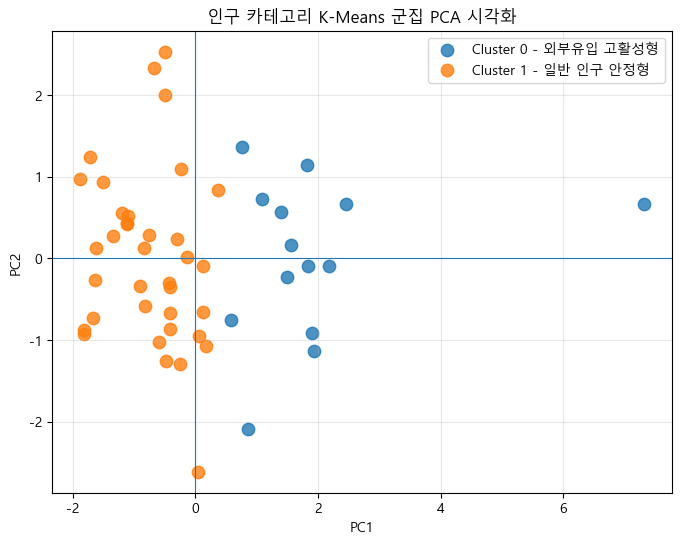

In [47]:
# =========================================================
# 16단계. PCA 산점도
# =========================================================

plt.figure(figsize=(8, 6))

for cluster_id in sorted(pop_pca_df["pop_cluster"].unique()):
    temp = pop_pca_df[pop_pca_df["pop_cluster"] == cluster_id]
    
    plt.scatter(
        temp["PC1"],
        temp["PC2"],
        label=f"Cluster {cluster_id} - {temp['pop_cluster_name'].iloc[0]}",
        s=80,
        alpha=0.8
    )

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.title("인구 카테고리 K-Means 군집 PCA 시각화")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

인구 카테고리 K-Means 결과를 PCA로 2차원 시각화한 결과,
외부유입 고활성형 군집은 주로 PC1 양의 방향에,
일반 인구 안정형 군집은 PC1 음의 방향에 분포하였다.

이를 통해 인구 변수 4개를 기준으로 두 군집이 일정 부분 구분되는 것을 확인하였다.